# OpenAlex_Analysis

Can complete the OA numbers & APC analysis.


In [1]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [2]:
pd.set_option('display.max_columns', None)
colors = sns.color_palette('inferno_r')
color = sns.color_palette('inferno_r')[0]
WORKS_PICKLE = "2026_API_GRAB.pkl"
usd_to_cad = 1.39

In [3]:
with open(WORKS_PICKLE, 'rb') as file:
    works = pickle.load(file)

w_df = pd.DataFrame(works)
oa_df = pd.DataFrame.from_records(w_df['open_access'].values, index=w_df['open_access'].index)

In [4]:
oa_df['is_oa'].value_counts()

is_oa
True     619
False    302
Name: count, dtype: int64

In [5]:
oa_df[oa_df['oa_status'] != 'closed']['oa_status'].value_counts()

oa_status
hybrid     273
gold       185
diamond     87
bronze      38
green       36
Name: count, dtype: int64

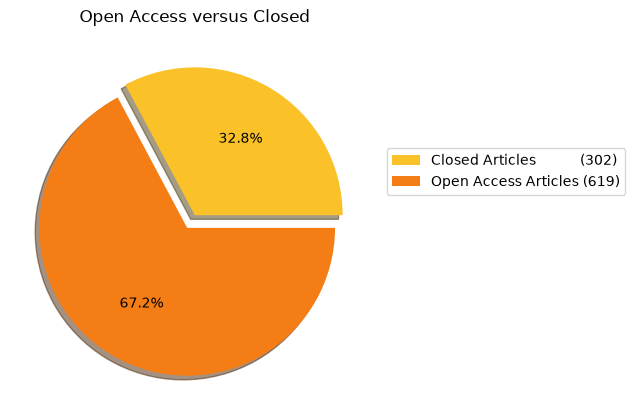

In [6]:
figname= "Open_Access_versus_Closed.png"
oa = len(oa_df[oa_df['is_oa'] == True])
not_oa = len(oa_df[oa_df['is_oa'] == False])
explode = (0, 0.1)
legend = ["Closed Articles           ("+str(not_oa)+")","Open Access Articles ("+str(oa)+")"]

plt.pie([not_oa,oa],autopct="%1.1f%%",explode=explode,shadow=True,startangle=0,colors=colors)
plt.legend(legend,bbox_to_anchor=(1.0,0.7))
plt.title("Open Access versus Closed")

figname = "Open_Access_versus_Closed.png"
plt.savefig(figname, bbox_inches='tight')

plt.show()

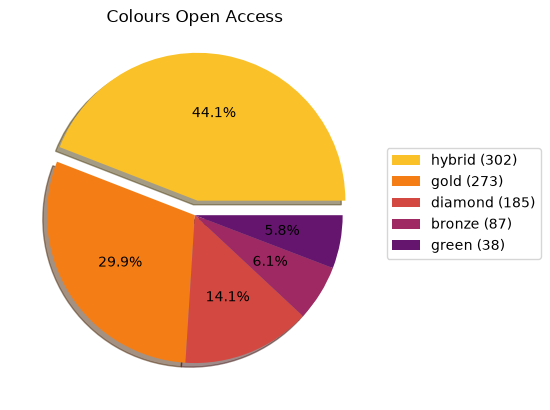

In [7]:
#Colors of OA

oa_colors = oa_df[oa_df['oa_status']!='closed']['oa_status'].value_counts().values
legend = oa_df[oa_df['oa_status']!='closed']['oa_status'].value_counts().index
legend = ['%s (%1d)' % (l, s) for l, s in zip(oa_df[oa_df['oa_status']!='closed']['oa_status'].value_counts().index, oa_df['oa_status'].value_counts().values)]

explode = list((0.0,) * len(oa_df[oa_df['oa_status']!='closed']['oa_status'].value_counts().index))
explode[0] = 0.1
explode = tuple(explode)


plt.pie(oa_colors,shadow=True, autopct="%1.1f%%", explode=explode, startangle=0,colors=colors)
plt.legend(legend,bbox_to_anchor=(1.0,0.7))
plt.title("Colours Open Access")

figname = "Colours_of_Open_Access.png"
plt.savefig(figname, bbox_inches='tight')

plt.show()

# APC Analysis

In [8]:

apc_data_list = []
apc_paid_list  = []
apc_cad_list = []

for work in works:
  try:
    apc_list = work.get('apc_list')['value_usd']
  except:
    apc_list = np.nan

  try:
    apc_paid = work.get('apc_paid')['value_usd']
    apc_cad = work.get('apc_paid')['value_usd'] * usd_to_cad
  except:
    apc_paid = np.nan
    apc_cad = np.nan

  apc_data_list.append(apc_list)
  apc_paid_list.append(apc_paid)
  apc_cad_list.append(apc_cad)

apc_df = pd.DataFrame(zip(apc_data_list,apc_paid_list,apc_cad_list),columns=['APC','Amount Paid (USD)','Amount Paid (CAD)'])


In [9]:
#total amount of APCS paid
apc_df['Amount Paid (CAD)'].sum()

np.float64(1838999.1899999997)

In [10]:
#total APC data retrieved
apc_df['APC'].sum() * usd_to_cad

np.float64(2691550.13)

In [11]:
#mean paid APCs
apc_df['Amount Paid (CAD)'].mean()

np.float64(4643.9373484848475)

In [12]:
#median paid APCS
apc_df['Amount Paid (CAD)'].median()

np.float64(4705.15)

In [13]:
#total of DOIs with APCs
apc_df['APC'].count()

np.int64(563)

In [14]:
#portion of DOIs with APCs
apc_df['APC'].count() / len(apc_df['APC'])

np.float64(0.6112920738327905)

In [15]:
#portion of DOIs that were paid
apc_df['Amount Paid (CAD)'].count()

np.int64(396)

In [16]:
#portion of paid APCs
apc_df['APC'].count() / len(apc_df['Amount Paid (CAD)'])

np.float64(0.6112920738327905)